In [4]:
import json
import requests
import pandas as pd

# Charger les données
base_url = "https://api-base-fastapi-mpt-dkhjb0cydga2aydc.canadacentral-01.azurewebsites.net"
api_key = ""
with open('../api.json', 'r') as file:
    api_key = json.load(file)["GH_API_KEY"]

def get_call(paths,url=base_url, params=None, header=None):
    url = f"{base_url}/{paths}"
    response = requests.get(url, params=params, headers=header)
    if response.status_code == 200:
        return response.json()
    elif response.status_code == 403:
        print("La patience est d'or. Enculé")
        response = requests.get(url, params=params, headers=header)
        return response.json()
    else:
        print(f"Error: {response.status_code} - {response.json().get('message', 'Unknown error')}")
        return None
repositories = get_call(paths="show_data",params={"page_size":100000,"page":1})

In [5]:
df = pd.DataFrame(repositories['data'])
df.to_pickle("repositories_data.pkl")
# df = df['language'].value_counts()[df['language'].value_counts()>10]

In [1]:
import pandas as pd
df = pd.read_pickle("repositories_data.pkl")
df = df[~df["language"].isin(["Python", "None"])]
df = df.dropna(subset=["language"])
df

,id,node_id,name,full_name,private,owner,html_url,description,fork,created_at,updated_at,pushed_at,language,forks_count,stargazers_count,watchers_count,open_issues_count,value
2,781629207.0,R_kgDOLpa3Fw,khalti-Integration-Component-Node,rose-rawal/khalti-Integration-Component-Node,False,"{'login': 'rose-rawal', 'id': 77530217, 'html_...",https://github.com/rose-rawal/khalti-Integrati...,Node configuration for khalti Integration,False,2024-04-03T18:38:17Z,2024-11-15T10:46:42Z,2024-04-03T19:01:23Z,JavaScript,0.0,5.0,5.0,0.0,NaN
3,781529358.0,R_kgDOLpUxDg,ms-springboot-324-java-22-jakarta-ee-10,arafkarsh/ms-springboot-324-java-22-jakarta-ee-10,False,"{'login': 'arafkarsh', 'id': 11264297, 'html_u...",https://github.com/arafkarsh/ms-springboot-324...,Microservice with SpringBoot 3.2.4 with Java 2...,False,2024-04-03T14:56:26Z,2025-01-20T03:41:10Z,2024-10-01T06:30:45Z,Java,0.0,5.0,5.0,0.0,NaN
4,781244528.0,R_kgDOLpDYcA,AndroidPipeline,linversion/AndroidPipeline,False,"{'login': 'linversion', 'id': 37201297, 'html_...",https://github.com/linversion/AndroidPipeline,Docker + Jenkins pipeline + AabResguard构建打包流程,False,2024-04-03T02:35:01Z,2025-01-21T06:42:12Z,2024-07-11T08:42:53Z,Shell,3.0,5.0,5.0,0.0,NaN
5,781609847.0,R_kgDOLpZrdw,Argochain,Devolved-AI/Argochain,False,"{'login': 'Devolved-AI', 'id': 143654570, 'htm...",https://github.com/Devolved-AI/Argochain,Your Gateway to the ArgoChain Network,False,2024-04-03T17:54:51Z,2025-02-05T11:54:56Z,2025-02-10T10:23:14Z,Rust,0.0,5.0,5.0,1.0,NaN
6,781360194.0,R_kgDOLpKcQg,PotPlayer-Obsidian,operations4304/PotPlayer-Obsidian,False,"{'login': 'operations4304', 'id': 155797197, '...",https://github.com/operations4304/PotPlayer-Ob...,None,False,2024-04-03T08:29:47Z,2025-02-08T16:46:22Z,2025-01-29T07:43:31Z,HTML,0.0,5.0,5.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,627408.0,MDEwOlJlcG9zaXRvcnk2Mjc0MDg=,Blog-Mvc2,GillyInOz/Blog-Mvc2,False,{},https://github.com/GillyInOz/Blog-Mvc2,Some sacred learnings of MVC2 - Use at your ow...,False,2010-04-25T01:03:45,2013-12-08T03:03:47,2010-05-03T04:32:03,JavaScript,0.0,1.0,1.0,0.0,NaN
99996,744958742.0,R_kgDOLGcrFg,paraglide-sveltekit-example,LorisSigrist/paraglide-sveltekit-example,False,"{'login': 'LorisSigrist', 'id': 43482866, 'htm...",https://github.com/LorisSigrist/paraglide-svel...,None,False,2024-01-18T10:59:17Z,2025-01-12T20:58:49Z,2024-07-12T08:45:34Z,Svelte,4.0,11.0,11.0,2.0,NaN
99997,744858239.0,R_kgDOLGWifw,OpenCSD-Management-Controller,opencsd/OpenCSD-Management-Controller,False,"{'login': 'opencsd', 'id': 85543439, 'html_url...",https://github.com/opencsd/OpenCSD-Management-...,None,False,2024-01-18T06:32:09Z,2025-01-16T01:59:42Z,2025-01-16T01:59:36Z,Go,7.0,11.0,11.0,0.0,NaN
99998,744859142.0,R_kgDOLGWmBg,RUI3-Best-Practice,RAKWireless/RUI3-Best-Practice,False,"{'login': 'RAKWireless', 'id': 23307155, 'html...",https://github.com/RAKWireless/RUI3-Best-Practice,This repo provides additional examples for RUI...,False,2024-01-18T06:34:53Z,2025-02-07T08:03:04Z,2025-02-07T08:02:59Z,C++,6.0,11.0,11.0,0.0,NaN


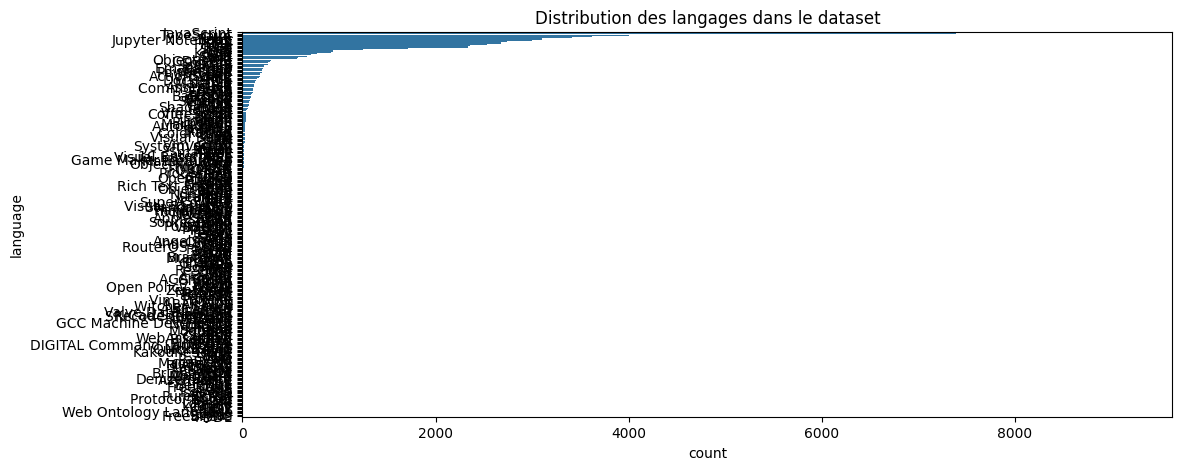

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sns.countplot(y=df["language"], order=df["language"].value_counts().index)
plt.title("Distribution des langages dans le dataset")
plt.show()

In [3]:
from train import train_log

acc = train_log(df,model_name="random_forest",epochs=10, batch_size=256)
print(f"Modèle entraîné avec une accuracy de {acc}")


📈 Entraînement des epochs:   0%|          | 0/10 [00:00<?, ?it/s]


🔄 Epoch 1/10...


📈 Entraînement des epochs:  10%|█         | 1/10 [00:04<00:37,  4.20s/it]

🎯 Accuracy: 0.0816

🔄 Epoch 2/10...


📈 Entraînement des epochs:  20%|██        | 2/10 [00:08<00:35,  4.40s/it]

...

🎯 Accuracy: 0.0892

🔄 Epoch 10/10...


📈 Entraînement des epochs: 100%|██████████| 10/10 [00:44<00:00,  4.46s/it]

🎯 Accuracy: 0.0844



2025/03/05 12:04:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'random_forest' already exists. Creating a new version of this model...
2025/03/05 12:04:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: random_forest, version 7
Created version '7' of model 'random_forest'.
2025/03/05 12:04:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: random_forest, version 8
c:\Users\a052080\Documents\MlOps\Big_Data_MLOps_Github_API\src\train.py:88: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migr

✅ Modèle random_forest enregistré en version 8
Modèle random_forest version 8 mis en production sur MLflow Serving!
🏃 View run beautiful-goose-119 at: http://localhost:8083/#/experiments/830273103893990900/runs/865c00ff3ec44776a3ffa258f56a4d91
🧪 View experiment at: http://localhost:8083/#/experiments/830273103893990900
Modèle entraîné avec une accuracy de 0.08441558441558442
